# Modélisation, Optimisation et Interprétabilité

Ce notebook s'appuie sur les résultats du notebook de prétraitement. Nous avons déterminé un pipeline de prétraitement optimal (imputation KNN, target encoding, transformation sqrt de la cible). Nous allons maintenant comparer plusieurs modèles de régression, optimiser les hyperparamètres du meilleur modèle, et enfin interpréter les prédictions à l'aide de SHAP.

## Plan

- **Modélisation** : Comparaison de 6 modèles (Ridge, SVR, AdaBoost, CatBoost, XGBoost, LightGBM, RandomForest) avec une fonction d'évaluation complète.
- **Optimisation** : Recherche guidée des meilleurs hyperparamètres pour le meilleur modèle.
- **Interprétabilité** : Analyse SHAP globale (Beeswarm) et locale.

---

## 1. Modélisation : Comparaison des modèles

### 1.1 Import des bibliothèques et chargement des données

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import cross_val_score, learning_curve, KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error, make_scorer, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.base import BaseEstimator, TransformerMixin

# Modèles boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Pour la recherche d'hyperparamètres
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Pour l'interprétabilité
import shap

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Chemins (à adapter si besoin)
notebooks_path = os.getcwd()
project_path = os.path.dirname(notebooks_path)
data_path = os.path.join(project_path, 'Data', 'DonneesPreparees', 'dataset_final.csv')
output_path = os.path.join(project_path, 'Outputs', 'Modelisation')
os.makedirs(output_path, exist_ok=True)

# Chargement des données
df = pd.read_csv(data_path)
print("Dimensions :", df.shape)
df.head()

Dimensions : (5065, 19)


,age_vehicule_annees,categorie_mère,contrat_id,cout_total_sinistres,duree_garantie_jours,garantie,marque,modèle,nb_sinistres,places,puissance,segment,type_vehicule,typeinter,typepermis,valeur_neuve,valeur_venale,y_cible,ville
0,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Dommages,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE
1,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Incendie,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,51480,YAOUNDE
2,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Dommages,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE
3,0.982888,Flotte pro,20230301_20240229_1001-1120000299,0.0,365,Incendie,JAC,HFC 4251 KR1,0.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,51480,YAOUNDE
4,0.982888,Flotte pro,20230301_20240229_1001-1120000299,11687092.0,365,Dommages,JAC,HFC 4251 KR1,1.0,3.0,31.0,GENERALISTE,AUTRE,Bureau Direct,B,45000000.0,45000000.0,1116000,YAOUNDE


### 1.2 Définition du pipeline de prétraitement optimal
Nous récupérons les choix effectués dans le notebook de prétraitement.

In [4]:
from sklearn.model_selection import GroupShuffleSplit


#Variables
cols_to_use = [
    'age_vehicule_annees',
    'duree_garantie_jours',
    'places',
    'puissance',
    'categorie_mère',
    'garantie',
    'segment',
    'typeinter',
    'y_cible',
    'contrat_id',
    'ville',
    'marque'
]

df_model = df[cols_to_use].copy()

num_cols = [
    'age_vehicule_annees',
    'duree_garantie_jours',
    'places',
    'puissance'
]

cat_cols = [
    'categorie_mère',
    'garantie',
    'segment',
    'typeinter',
    'ville',
    'marque'
]

X = df_model[num_cols + cat_cols]
y = df_model['y_cible']
groups = df_model['contrat_id']


# Première séparation : Train+Eval / Test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

train_eval_idx, test_idx = next(gss_test.split(X, y, groups))

X_train_eval = X.iloc[train_eval_idx]
y_train_eval = y.iloc[train_eval_idx]
groups_train_eval = groups.iloc[train_eval_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]
groups_test = groups.iloc[test_idx]



# Deuxième séparation : Train / Evaluation
# On veut 20 % du dataset total pour Evaluation.
# Comme Train+Eval représente 80 %, il faut :
#
# 20 / 80 = 25 %
#
# de Train+Eval pour l'évaluation.

gss_eval = GroupShuffleSplit(n_splits=1,test_size=0.25, random_state=42)

train_idx, eval_idx = next(gss_eval.split(X_train_eval, y_train_eval, groups_train_eval))

X_train = X_train_eval.iloc[train_idx]
y_train = y_train_eval.iloc[train_idx]

X_eval = X_train_eval.iloc[eval_idx]
y_eval = y_train_eval.iloc[eval_idx]

groups_train = groups_train_eval.iloc[train_idx]
groups_eval = groups_train_eval.iloc[eval_idx]

print(f"Train size: {len(X_train)}, Val size: {len(X_eval)}, Test size: {len(X_test)}")

# Préprocesseur final (basé sur les meilleures stratégies)
# Imputation: KNN pour numériques, mode pour catégorielles
# Encodage: Target Encoding pour catégorielles
# Pas de clipping des outliers (car 'aucun' était le meilleur selon la conclusion)

Train size: 3034, Val size: 832, Test size: 1199


In [5]:
X_train.head()

,age_vehicule_annees,duree_garantie_jours,places,puissance,categorie_mère,garantie,segment,typeinter,ville,marque
0,0.982888,365,3.0,31.0,Flotte pro,Dommages,GENERALISTE,Bureau Direct,YAOUNDE,JAC
1,0.982888,365,3.0,31.0,Flotte pro,Incendie,GENERALISTE,Bureau Direct,YAOUNDE,JAC
2,0.982888,365,3.0,31.0,Flotte pro,Dommages,GENERALISTE,Bureau Direct,YAOUNDE,JAC
3,0.982888,365,3.0,31.0,Flotte pro,Incendie,GENERALISTE,Bureau Direct,YAOUNDE,JAC
4,0.982888,365,3.0,31.0,Flotte pro,Dommages,GENERALISTE,Bureau Direct,YAOUNDE,JAC


In [6]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import category_encoders as ce

num_imputer = KNNImputer(n_neighbors=5)
cat_imputer = SimpleImputer(strategy='most_frequent')

# Target Encoder nécessite les colonnes catégorielles et la target
target_encoder = ce.TargetEncoder(
    smoothing=1,
    min_samples_leaf=10
)

num_pipeline = Pipeline([('imputer', num_imputer)])

cat_pipeline = Pipeline([('imputer', cat_imputer), ('encoder', target_encoder)])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [7]:
# Transformation de la cible : sqrt (meilleure stratégie)
y_train_trans = np.sqrt(np.maximum(0, y_train))
y_eval_trans = np.sqrt(np.maximum(0, y_eval))
y_test_trans = np.sqrt(np.maximum(0, y_test))

# Note : nous allons intégrer la transformation de la cible dans les pipelines via TransformedTargetRegressor

### 1.3 Fonction d'évaluation personnalisée
Nous définissons une fonction evaluate_model qui prend un modèle (non entraîné), l'entraîne sur les données transformées, et évalue ses performances sur train et test selon plusieurs métriques.

Métriques :

RMSE (Root Mean Squared Error)

RMSLE (Root Mean Squared Logarithmic Error) : on ajoute 1 aux valeurs pour éviter log(0)

MAE (Mean Absolute Error)

Métrique personnalisée : moyenne des valeurs absolues des prédictions négatives (pour pénaliser les prédictions inférieures à 0)

La fonction affiche également :

Les métriques sur train et test

La courbe d'apprentissage (learning curve) sur 5 plis

La variabilité des scores en validation croisée (boxplot) avec moyenne et écart-type

Un histogramme des résidus sur le jeu de test

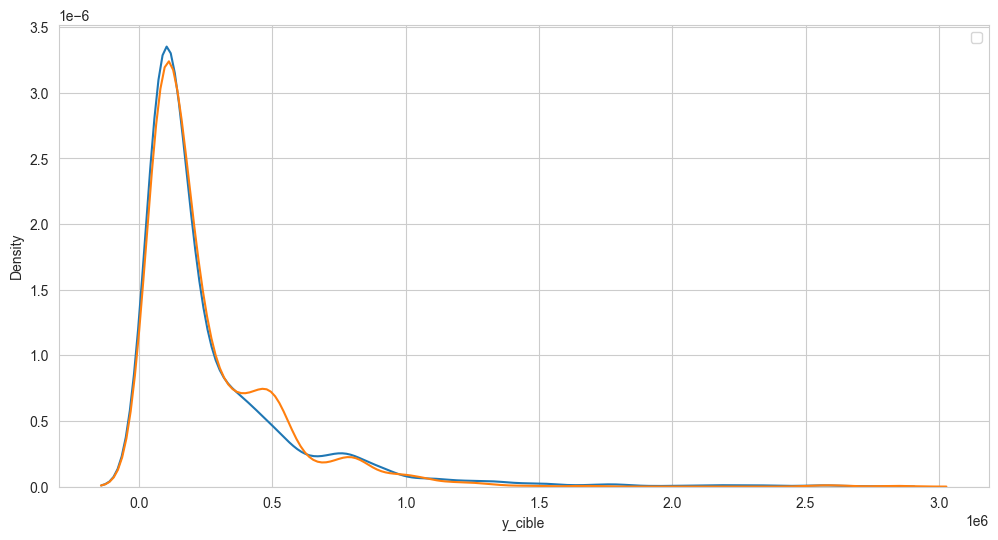

In [8]:
# Graphique pour visualiser les distributions de y dans le train et dans le test
# L'idée est que nous devons préserver au maximum la distribution de y
plt.figure()
sns.kdeplot(x=y_train)
sns.kdeplot(x=y_test)
#sns.kdeplot(x=y_eval)
plt.legend()
plt.show()

In [9]:
from sklearn.model_selection import cross_val_score, learning_curve, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def pos_pred_penalty(y_true, y_pred):
    """
    Métrique personnalisée : moyenne des valeurs absolues des erreurs positives.
    Plus elle est faible, mieux c'est (idéalement 0).
    """
    pos_preds = y_true - y_pred
    pos_preds = pos_preds[pos_preds > 0]
    if len(pos_preds) == 0:
        return 0.0
    return np.mean(np.abs(pos_preds))


def taux_sous_estimation(y_true, y_pred):
    """
    Calcule le taux de sous-estimation.
    Une observation est considérée comme sous-estimée lorsque
    la prime prédite est inférieure à la prime cible.
    """
    
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    sous_estimes = y_pred < y_true

    return sous_estimes.mean() * 100

def evaluate_model(model, model_name, X_train, y_train, X_eval, y_eval, X_test, y_test,
                   groups_train=None, groups_eval=None, groups_test=None, cv=5,
                   scoring='neg_mean_squared_error'):
    """
    Entraîne et évalue un modèle avec :
    - Train + Evaluation pour l'entraînement final et la CV
    - X_eval/y_eval comme validation externe pour la learning curve
    - X_test/y_test comme jeu de test final
    - CV groupée par contrat si groups_train est fourni
    """

    # Concaténer Train + Evaluation pour l'entraînement

    X_train_full = pd.concat([X_train, X_eval], axis=0)
    y_train_full = pd.concat([y_train, y_eval], axis=0)

    if groups_train is not None and groups_eval is not None:
        groups_train_full = pd.concat([groups_train, groups_eval], axis=0)
    else:
        groups_train_full = None


    # Entraînement final sur Train + Evaluation

    model.fit(X_train_full, y_train_full)

    y_train_pred = np.clip(model.predict(X_train_full), 0, None)
    y_test_pred = np.clip(model.predict(X_test), 0, None)


    # Retour à l'échelle originale
    y_train_orig = y_train_full ** 2
    y_test_orig = y_test ** 2
    y_train_pred_orig = y_train_pred ** 2
    y_test_pred_orig = y_test_pred ** 2


    # Métriques Train + Evaluation

    rmse_train = np.sqrt(mean_squared_error(y_train_full, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    r2_train = r2_score(y_train_orig + 1, y_train_pred_orig)
    r2_test = r2_score(y_test_orig + 1, y_test_pred_orig)

    rmsle_train = np.sqrt(mean_squared_log_error(y_train_orig + 1, y_train_pred_orig + 1))
    rmsle_test = np.sqrt(mean_squared_log_error(y_test_orig + 1, y_test_pred_orig + 1))

    mae_train = mean_absolute_error(y_train_orig, y_train_pred_orig)
    mae_test = mean_absolute_error(y_test_orig, y_test_pred_orig)

    pos_penalty_train = pos_pred_penalty(y_train_orig, y_train_pred_orig)
    pos_penalty_test = pos_pred_penalty(y_test_orig, y_test_pred_orig)

    taux_train = taux_sous_estimation(y_train_orig, y_train_pred_orig)
    taux_test = taux_sous_estimation(y_test_orig, y_test_pred_orig)


    # Affichage des métriques

    print(f"\n{'='*50}")
    print(f"Modèle : {model_name}")
    print(f"{'='*50}")
    print(f"R carré (train+eval): {r2_train:.4f}  (test) : {r2_test:.4f}")
    print(f"RMSE (train+eval) : {rmse_train:.4f}  (test) : {rmse_test:.4f}")
    print(f"RMSLE (train+eval) : {rmsle_train:.4f}  (test) : {rmsle_test:.4f}")
    print(f"MAE (train+eval) : {mae_train:.4f}  (test) : {mae_test:.4f}")
    print(f"Mean Abs. Pos. Error (train+eval) : {pos_penalty_train:.4f}  (test) : {pos_penalty_test:.4f}")
    print(f"Taux de sous-estimation (train+eval): {taux_train:.2f}%   (test) : {taux_test:.2f}%")


    # Validation croisée sur Train + Evaluation

    if groups_train_full is not None:
        cv_splitter = GroupKFold(n_splits=cv)
        cv_scores = cross_val_score(model, X_train_full, y_train_full, groups=groups_train_full,
                                    cv=cv_splitter, scoring=scoring, n_jobs=-1)
    else:
        cv_splitter = KFold(n_splits=cv, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train_full, y_train_full, cv=cv_splitter,
                                    scoring=scoring, n_jobs=-1)

    cv_rmse = np.sqrt(-cv_scores)
    mean_cv = np.mean(cv_rmse)
    std_cv = np.std(cv_rmse)
    print(f"CV RMSE (moyenne ± écart-type) : {mean_cv:.4f} ± {std_cv:.4f}")


    # Learning curve : Train + Evaluation → X_eval

    train_sizes = np.linspace(0.1, 1.0, 10)
    train_rmse = []
    eval_rmse = []

    # On utilise uniquement X_train_full pour construire les tailles
    n_samples = len(X_train_full)

    rng = np.random.RandomState(42)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    for fraction in train_sizes:
        n_train = max(1, int(fraction * n_samples))
        subset_idx = indices[:n_train]

        X_subset = X_train_full.iloc[subset_idx]
        y_subset = y_train_full.iloc[subset_idx]

        model_clone = clone(model)
        model_clone.fit(X_subset, y_subset)

        y_subset_pred = np.clip(model_clone.predict(X_subset), 0, None)
        y_eval_pred = np.clip(model_clone.predict(X_eval), 0, None)

        train_rmse.append(np.sqrt(mean_squared_error(y_subset, y_subset_pred)))
        eval_rmse.append(np.sqrt(mean_squared_error(y_eval, y_eval_pred)))

    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes * n_samples, train_rmse, 'o-', label='Train RMSE')
    plt.plot(train_sizes * n_samples, eval_rmse, 'o-', label='Evaluation RMSE')
    plt.xlabel("Taille de l'échantillon d'entraînement")
    plt.ylabel("RMSE")
    plt.title(f"Courbe d'apprentissage - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


    # Boxplot des scores CV

    cv_scores_list = []

    if groups_train_full is not None:
        for train_idx, val_idx in cv_splitter.split(X_train_full, y_train_full, groups_train_full):
            X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            y_pred_val = np.clip(model_clone.predict(X_val), 0, None)
            cv_scores_list.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))
    else:
        for train_idx, val_idx in cv_splitter.split(X_train_full, y_train_full):
            X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
            y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            y_pred_val = np.clip(model_clone.predict(X_val), 0, None)
            cv_scores_list.append(np.sqrt(mean_squared_error(y_val, y_pred_val)))

    plt.figure(figsize=(8, 5))
    sns.boxplot(y=cv_scores_list, color='skyblue')
    plt.ylabel('RMSE')
    plt.title(f'Variabilité des scores CV - {model_name}')
    plt.grid(True)
    plt.show()


    # Résidus sur le Test uniquement

    residuals = y_test_orig - y_test_pred_orig

    plt.figure(figsize=(10, 5))
    sns.histplot(residuals, bins=50, kde=True)
    plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
    plt.xlabel('Résidu (valeur réelle - prédiction)')
    plt.ylabel('Fréquence')
    plt.title(f'Distribution des résidus sur le test set - {model_name}')
    plt.legend()
    plt.grid(True)
    plt.show()


    # Résultats

    metrics = {
        'model': model_name,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'rmsle_train': rmsle_train,
        'rmsle_test': rmsle_test,
        'mae_train': mae_train,
        'mae_test': mae_test,
        'pos_penalty_train': pos_penalty_train,
        'pos_penalty_test': pos_penalty_test,
        'taux_sous_estimation_train': taux_train,
        'taux_sous_estimation_test': taux_test,
        'cv_mean': mean_cv,
        'cv_std': std_cv
    }

    return metrics

### 1.4 Préparation des données pour les modèles
Nous appliquons le préprocesseur pour obtenir les données numériques. Attention : le target encoder a besoin de la target, nous le faisons donc en deux étapes.

In [10]:
# Fit du preprocessing
X_train_processed = preprocessor.fit_transform(X_train, y_train_trans)
X_eval_processed = preprocessor.transform(X_eval)
X_test_processed = preprocessor.transform(X_test)

# Récupération des noms
feature_names = []

for name, transformer, cols in preprocessor.transformers_:
    if name == 'remainder':
        continue
    
    # Variables numériques : gardent leurs noms
    if name == 'num':
        feature_names.extend(cols)
    
    # Variables catégorielles TargetEncoder : gardent leurs noms
    elif name == 'cat':
        feature_names.extend(cols)

# DataFrame final
X_train_proc_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_eval_proc_df = pd.DataFrame(X_eval_processed, columns=feature_names, index=X_eval.index)
X_test_proc_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(X_train_proc_df.columns)

Index(['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance',
       'categorie_mère', 'garantie', 'segment', 'typeinter', 'ville',
       'marque'],
      dtype='object')


In [11]:
print(f"========== Colonnes de X avant l'application du preprocessor ==========: \n {X_train.columns}")
print()
#print(f"========== Preprocessor ==========\n{preprocessor}")
print()
print(f"========== Colonnes de X après l'application du preprocessor ==========:\n {X_train_proc_df.columns}")

========== Colonnes de X avant l'application du preprocessor ==========: 
 Index(['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance',
       'categorie_mère', 'garantie', 'segment', 'typeinter', 'ville',
       'marque'],
      dtype='object')


========== Colonnes de X après l'application du preprocessor ==========:
 Index(['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance',
       'categorie_mère', 'garantie', 'segment', 'typeinter', 'ville',
       'marque'],
      dtype='object')


### 1.5 Définition des modèles à comparer
Nous définissons une liste de modèles avec leurs paramètres par défaut.

In [12]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

models = {
    'Ridge': Pipeline(steps=[
        ('Feature Engineering', PolynomialFeatures(degree=3, include_bias=False)),
        ('Modelling', Ridge(alpha=1.5, random_state=42)),
    ]),
    #'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    #'AdaBoost': AdaBoostRegressor(n_estimators=500, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=1000, max_depth = 3, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=1000, max_depth = 3, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=1000, max_depth = 3, random_seed=42, verbose=False)
}

### 1.6 Évaluation de chaque modèle
Nous allons itérer sur les modèles, appeler evaluate_model et stocker les métriques pour comparaison.

In [13]:
y_test.min()

np.int64(50000)

In [14]:
print(X_train_proc_df.shape), print(y_train_trans.shape)
print(X_eval_proc_df.shape), print(y_eval_trans.shape)
print(X_test_proc_df.shape), print(y_test_trans.shape)

(3034, 10)
(3034,)
(832, 10)
(832,)
(1199, 10)
(1199,)


(None, None)


--- Évaluation de Ridge ---

Modèle : Ridge
R carré (train+eval): 0.5791  (test) : -24.5138
RMSE (train+eval) : 152.4452  (test) : 286.4828
RMSLE (train+eval) : 0.5982  (test) : 1.6542
MAE (train+eval) : 121626.9827  (test) : 194808.2194
Mean Abs. Pos. Error (train+eval) : 161417.1863  (test) : 193187.2176
Taux de sous-estimation (train+eval): 44.90%   (test) : 49.21%
CV RMSE (moyenne ± écart-type) : 1765.9901 ± 1490.4899


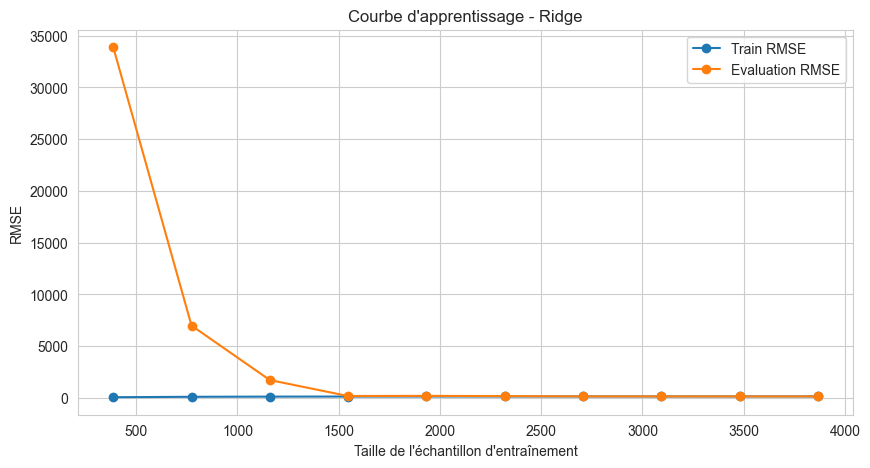

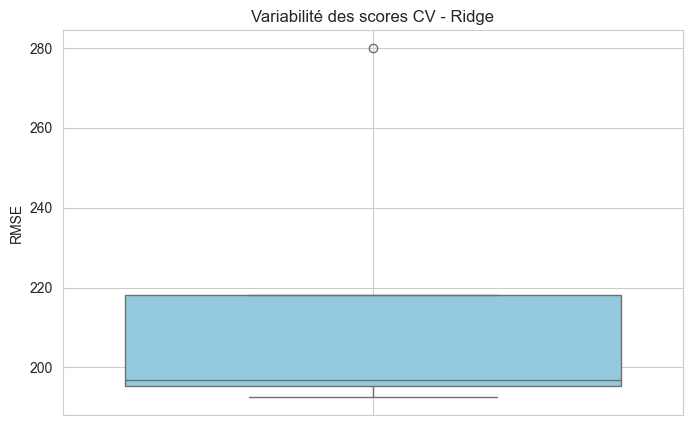

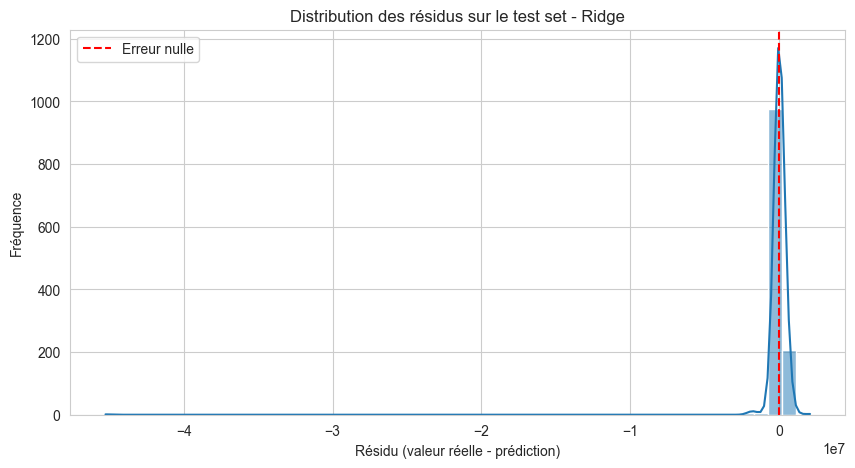


--- Évaluation de RandomForest ---

Modèle : RandomForest
R carré (train+eval): 0.9221  (test) : 0.2282
RMSE (train+eval) : 69.1908  (test) : 196.3557
RMSLE (train+eval) : 0.2760  (test) : 0.8175
MAE (train+eval) : 39610.5438  (test) : 144973.4413
Mean Abs. Pos. Error (train+eval) : 51800.3129  (test) : 162499.3355
Taux de sous-estimation (train+eval): 46.51%   (test) : 54.88%
CV RMSE (moyenne ± écart-type) : 127.4425 ± 6.1708


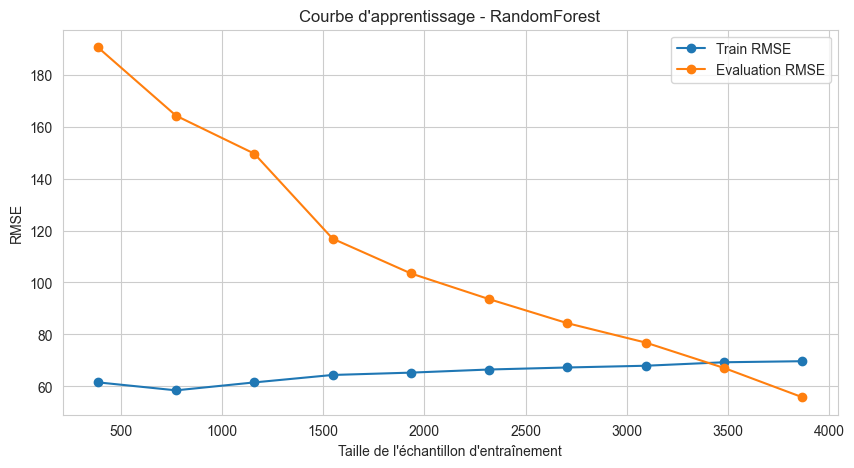

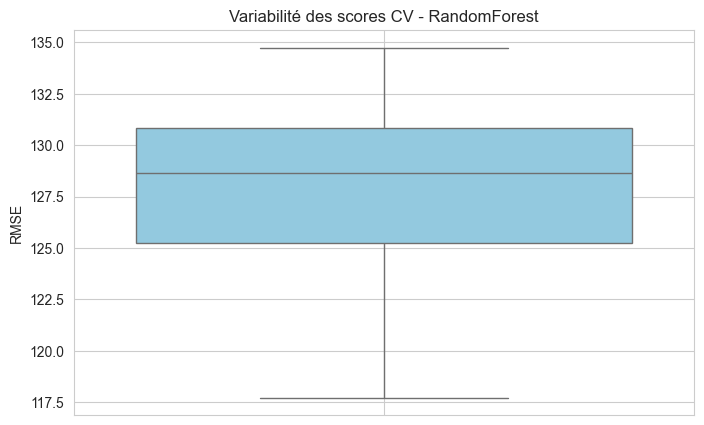

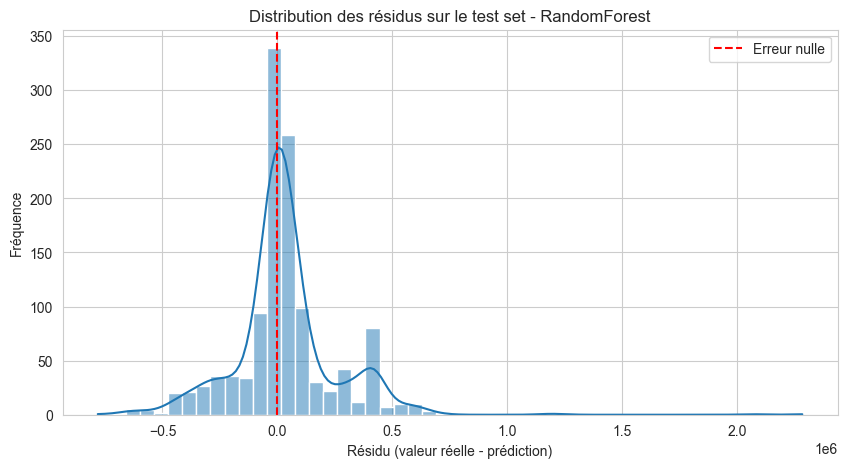


--- Évaluation de XGBoost ---

Modèle : XGBoost
R carré (train+eval): 0.8954  (test) : -0.0476
RMSE (train+eval) : 81.9077  (test) : 222.5804
RMSLE (train+eval) : 0.3370  (test) : 0.9883
MAE (train+eval) : 55184.7890  (test) : 167432.4949
Mean Abs. Pos. Error (train+eval) : 66758.0686  (test) : 151845.7517
Taux de sous-estimation (train+eval): 48.86%   (test) : 56.13%
CV RMSE (moyenne ± écart-type) : 124.8927 ± 1.1453


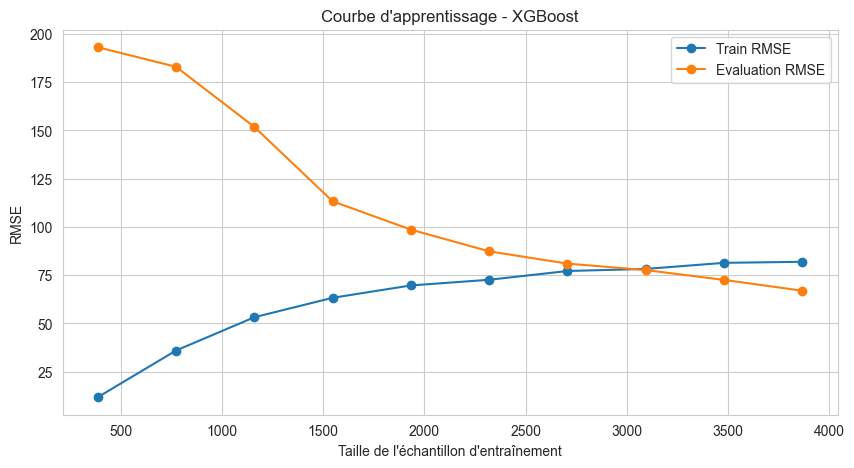

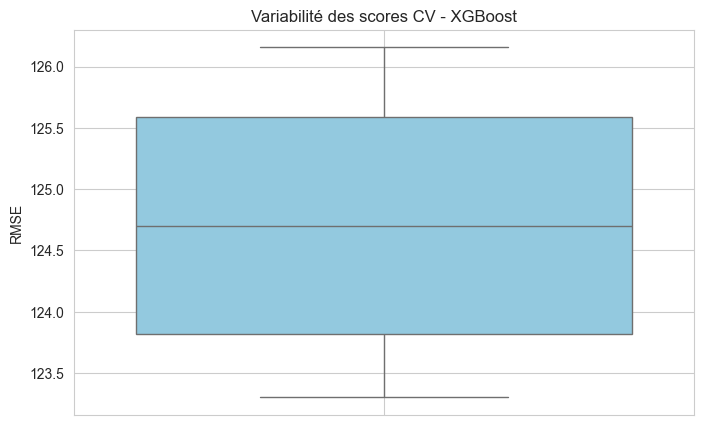

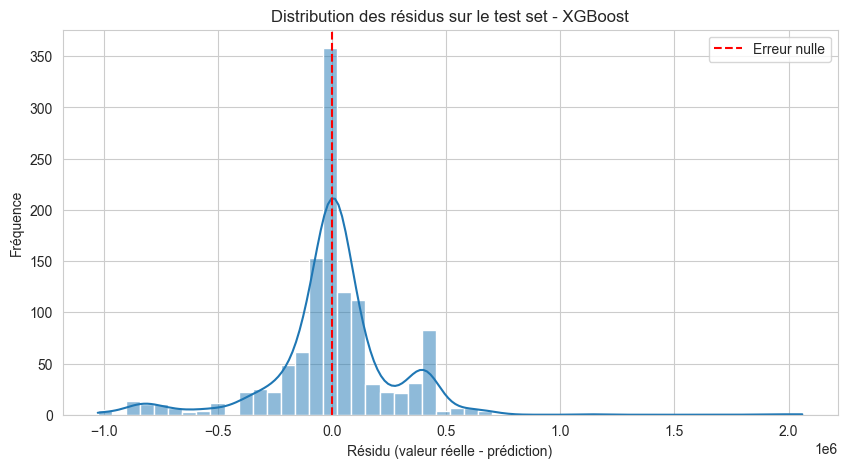


--- Évaluation de LightGBM ---

Modèle : LightGBM
R carré (train+eval): 0.7868  (test) : 0.2072
RMSE (train+eval) : 108.4462  (test) : 195.7515
RMSLE (train+eval) : 0.4264  (test) : 0.8080
MAE (train+eval) : 82389.6260  (test) : 147864.9005
Mean Abs. Pos. Error (train+eval) : 102082.4498  (test) : 148012.7947
Taux de sous-estimation (train+eval): 48.68%   (test) : 57.80%
CV RMSE (moyenne ± écart-type) : 131.1234 ± 2.3212


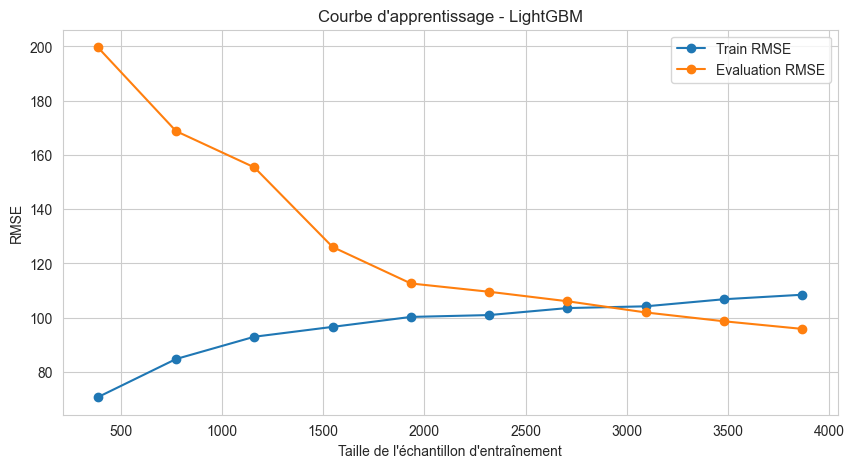

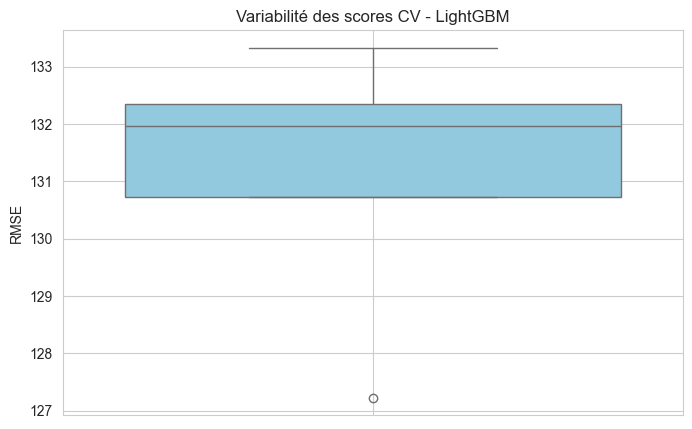

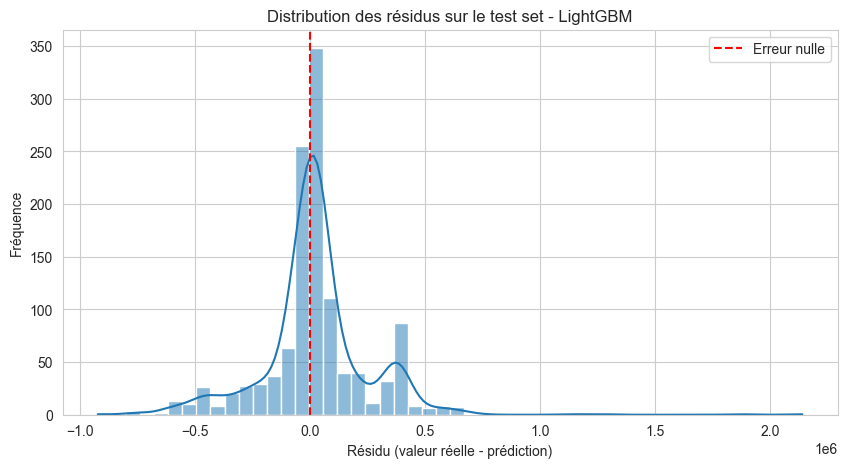


--- Évaluation de CatBoost ---

Modèle : CatBoost
R carré (train+eval): 0.7021  (test) : 0.2738
RMSE (train+eval) : 126.2989  (test) : 183.0390
RMSLE (train+eval) : 0.4838  (test) : 0.7360
MAE (train+eval) : 99575.5428  (test) : 141681.4970
Mean Abs. Pos. Error (train+eval) : 141189.5922  (test) : 147964.3808
Taux de sous-estimation (train+eval): 43.38%   (test) : 57.80%
CV RMSE (moyenne ± écart-type) : 139.5522 ± 0.9187


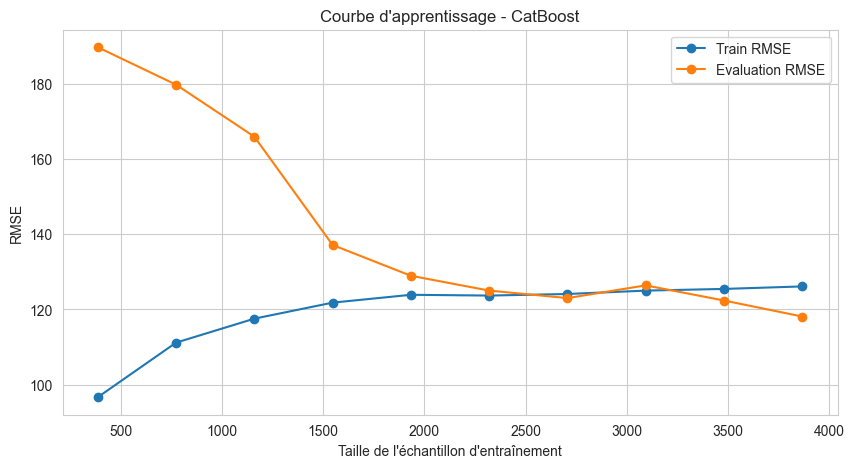

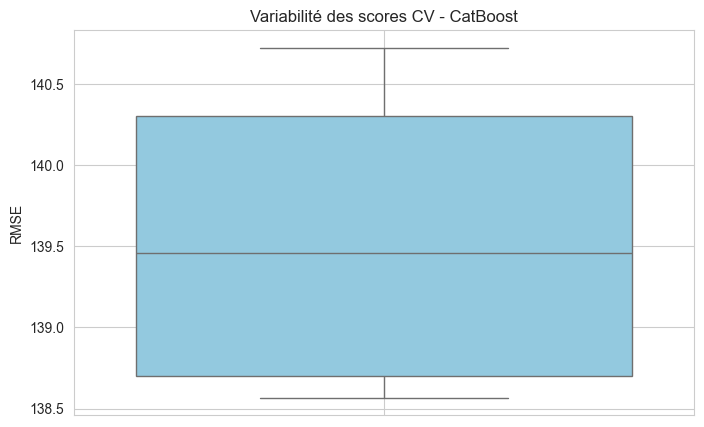

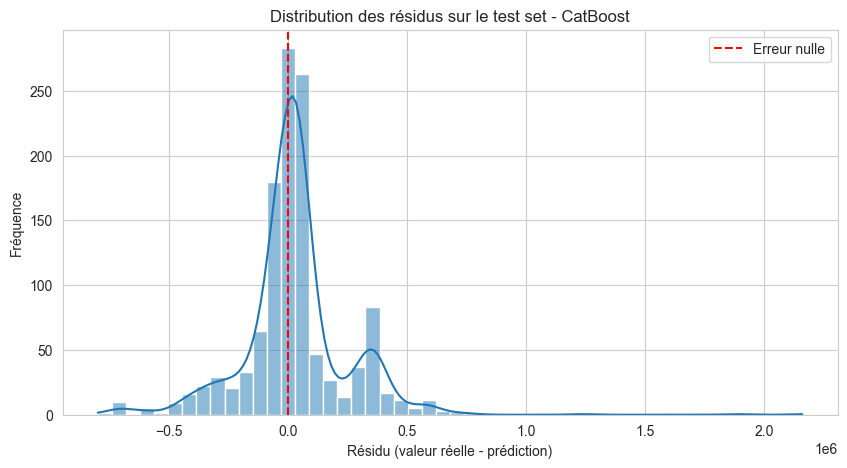

In [15]:
results = []

for name, model in models.items():
    print(f"\n--- Évaluation de {name} ---")
    # Note : on entraîne directement sur les données transformées (car le preprocesseur est déjà appliqué)
    # mais on garde la transformation de la cible en sqrt (on a déjà transformé y_train_trans)
    metrics = evaluate_model(
        model, name,
        X_train_proc_df, y_train_trans,
        X_eval_proc_df, y_eval_trans,
        X_test_proc_df, y_test_trans,
        cv=4
    )
    results.append(metrics)

# DataFrame comparatif
df_results = pd.DataFrame(results)
df_results = df_results.set_index('model')

In [16]:
print("\nRésumé comparatif des modèles :")
display(df_results[['rmse_train', 'rmse_test', 'rmsle_train', 'rmsle_test', 'mae_train', 'mae_test', 'pos_penalty_test', 'cv_mean', 'cv_std']])
perf_models_path = os.path.join(output_path, 'comparaison_modèles.xlsx')
df_results.to_excel(perf_models_path, index=False)


Résumé comparatif des modèles :


,rmse_train,rmse_test,rmsle_train,rmsle_test,mae_train,mae_test,pos_penalty_test,cv_mean,cv_std
model,,,,,,,,,
Ridge,152.445244,286.482765,0.598197,1.654182,121626.982729,194808.219354,193187.217636,1765.990142,1490.489922
RandomForest,69.190766,196.355689,0.275975,0.817464,39610.543824,144973.441264,162499.335538,127.442512,6.170846
XGBoost,81.907742,222.580424,0.337020,0.988341,55184.789041,167432.494899,151845.751702,124.892687,1.145285
LightGBM,108.446216,195.751527,0.426393,0.807951,82389.626042,147864.900525,148012.794734,131.123420,2.321206
CatBoost,126.298869,183.039030,0.483751,0.735980,99575.542775,141681.497013,147964.380812,139.552173,0.918651


## Choix du meilleur modèle
Le **RandomForest** est retenu comme le meilleur modèle compte tenu de :
- La validation croisée qui nous donne l'erreur moyenne la plus faible (CV mean = 785.1159 ± 50.3750)
- Le meilleur (le plus petit) Root Mean Squared Logarithmic Error sur le test (1,3537). Ce qui signifie que les **prédictions sont en moyenne à ± exp(1,3537) c'est à dire ± 3,872 % de la valeur réelle**.
- La meilleure (la plus petite) moyenne des erreurs positives (6 486 323). **Une erreur positive <=> y_reel - y_predit > 0 <=> y_predit < y_reel; ce qui est une perte pour la compagnie**. 
- Le meilleur (le plus faible) taux de sous estimation des primes (44,71%).
- Le meilleur R carré sur l'ensemble de test (0,8823)
- De plus, **la courbe d'apprentissage monte que les performances de validations ne sont pas très loin des performances de test, les deux courbes se touchent également, prouvant qu'il y'a absolument un problème d'overfitting.**

## 2. Optimisation des hyperparamètres de RandomForest

Le modèle RandomForest a été sélectionné comme le plus performant en comparaison initiale. Nous allons maintenant affiner ses hyperparamètres pour améliorer encore ses performances.

### 2.1 Définition de la grille de recherche

Nous définissons une grille d'hyperparamètres à explorer avec `Optuna`. Cette approche est plus efficace qu'une recherche exhaustive quand l'espace de recherche est grand.

**Hyperparamètres clés pour RandomForest** :
- n_estimators   : nombre d'arbres
- max_depth      : profondeur maximale de chaque arbre (None = illimitée)
- min_samples_split : nombre minimum d'échantillons pour diviser un nœud
- min_samples_leaf  : nombre minimum d'échantillons dans une feuille
- max_features   : fraction des caractéristiques considérées pour chaque split
- max_samples    : fraction des échantillons utilisés pour entraîner chaque arbre (si bootstrap=True)
- bootstrap      : utilisation ou non du bootstrapping
- ccp_alpha      : paramètre de régularisation (complexité des arbres)

Nous limitons le nombre de combinaisons pour des raisons de temps de calcul.

### 2.2 Entraînement du modèle optimisé
Nous récupérons le meilleur estimateur et l'entraînons sur l'ensemble complet d'entraînement. Nous évaluons ensuite ses performances sur le test set.

In [17]:
import optuna
from sklearn.model_selection import KFold, cross_val_predict

# Fonction objectif Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_sample_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        "max_samples": trial.suggest_float("max_samples", 0.6, 1.0),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    cv = GroupKFold(n_splits=4)
    #KFold(n_splits=4, shuffle=True, random_state=42)
    y_pred_cv = cross_val_predict(model, X_train_proc_df, y_train_trans, groups=groups_train, cv=cv, n_jobs=-1)
    score = pos_pred_penalty(y_train_trans, y_pred_cv)

    return score

# Lancement de optuna
study = optuna.create_study(direction="minimize", study_name="RF_Assurance")
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-09-21 09:55:30,786] A new study created in memory with name: RF_Assurance
Best trial: 0. Best value: 136.041:   3%|▎         | 1/30 [00:02<00:59,  2.04s/it]

[I 2026-09-21 09:55:32,824] Trial 0 finished with value: 136.04072253801544 and parameters: {'n_estimators': 350, 'max_depth': 24, 'min_sample_split': 3, 'min_samples_leaf': 7, 'max_features': 0.6151368651674751, 'max_samples': 0.7850166063115971}. Best is trial 0 with value: 136.04072253801544.


Best trial: 0. Best value: 136.041:   7%|▋         | 2/30 [00:02<00:38,  1.37s/it]

[I 2026-09-21 09:55:33,723] Trial 1 finished with value: 143.48682465827994 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_sample_split': 17, 'min_samples_leaf': 10, 'max_features': 0.37336738783818346, 'max_samples': 0.9060640312316507}. Best is trial 0 with value: 136.04072253801544.


Best trial: 2. Best value: 131.911:  10%|█         | 3/30 [00:07<01:15,  2.80s/it]

[I 2026-09-21 09:55:38,220] Trial 2 finished with value: 131.91066696015997 and parameters: {'n_estimators': 500, 'max_depth': 21, 'min_sample_split': 18, 'min_samples_leaf': 2, 'max_features': 0.9203120020950966, 'max_samples': 0.9440527538043303}. Best is trial 2 with value: 131.91066696015997.


Best trial: 2. Best value: 131.911:  13%|█▎        | 4/30 [00:10<01:19,  3.06s/it]

[I 2026-09-21 09:55:41,671] Trial 3 finished with value: 133.02892378304952 and parameters: {'n_estimators': 450, 'max_depth': 30, 'min_sample_split': 3, 'min_samples_leaf': 7, 'max_features': 0.7056452326288353, 'max_samples': 0.8132629615152827}. Best is trial 2 with value: 131.91066696015997.


Best trial: 4. Best value: 131.698:  17%|█▋        | 5/30 [00:14<01:24,  3.38s/it]

[I 2026-09-21 09:55:45,629] Trial 4 finished with value: 131.6983780385093 and parameters: {'n_estimators': 400, 'max_depth': 21, 'min_sample_split': 16, 'min_samples_leaf': 6, 'max_features': 0.8943694803902928, 'max_samples': 0.9266832371194655}. Best is trial 4 with value: 131.6983780385093.


Best trial: 5. Best value: 130.397:  20%|██        | 6/30 [00:16<01:07,  2.81s/it]

[I 2026-09-21 09:55:47,328] Trial 5 finished with value: 130.39715533884848 and parameters: {'n_estimators': 150, 'max_depth': 24, 'min_sample_split': 4, 'min_samples_leaf': 2, 'max_features': 0.7522700723613767, 'max_samples': 0.7596931549272348}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  23%|██▎       | 7/30 [00:17<00:48,  2.12s/it]

[I 2026-09-21 09:55:48,023] Trial 6 finished with value: 143.85489790894337 and parameters: {'n_estimators': 100, 'max_depth': 19, 'min_sample_split': 16, 'min_samples_leaf': 8, 'max_features': 0.3280622174793208, 'max_samples': 0.7452737371862801}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  27%|██▋       | 8/30 [00:20<00:52,  2.37s/it]

[I 2026-09-21 09:55:50,941] Trial 7 finished with value: 141.85703847974065 and parameters: {'n_estimators': 400, 'max_depth': 9, 'min_sample_split': 11, 'min_samples_leaf': 4, 'max_features': 0.3658369489816725, 'max_samples': 0.7132363694473641}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  30%|███       | 9/30 [00:22<00:48,  2.30s/it]

[I 2026-09-21 09:55:53,091] Trial 8 finished with value: 131.66644966062054 and parameters: {'n_estimators': 250, 'max_depth': 27, 'min_sample_split': 7, 'min_samples_leaf': 4, 'max_features': 0.5471175806416666, 'max_samples': 0.8305571437811488}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  33%|███▎      | 10/30 [00:23<00:42,  2.10s/it]

[I 2026-09-21 09:55:54,734] Trial 9 finished with value: 148.91628680532475 and parameters: {'n_estimators': 250, 'max_depth': 5, 'min_sample_split': 11, 'min_samples_leaf': 1, 'max_features': 0.8372342748289667, 'max_samples': 0.8668207348791168}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  37%|███▋      | 11/30 [00:26<00:41,  2.19s/it]

[I 2026-09-21 09:55:57,138] Trial 10 finished with value: 135.85601584663 and parameters: {'n_estimators': 250, 'max_depth': 13, 'min_sample_split': 11, 'min_samples_leaf': 10, 'max_features': 0.9915090915369942, 'max_samples': 0.6098526848343062}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  40%|████      | 12/30 [00:27<00:35,  1.96s/it]

[I 2026-09-21 09:55:58,560] Trial 11 finished with value: 133.40325232349417 and parameters: {'n_estimators': 200, 'max_depth': 29, 'min_sample_split': 7, 'min_samples_leaf': 3, 'max_features': 0.532686823584883, 'max_samples': 0.6735767273038182}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  43%|████▎     | 13/30 [00:31<00:43,  2.54s/it]

[I 2026-09-21 09:56:02,444] Trial 12 finished with value: 132.21428130672808 and parameters: {'n_estimators': 300, 'max_depth': 26, 'min_sample_split': 7, 'min_samples_leaf': 4, 'max_features': 0.7481336228503466, 'max_samples': 0.8338980023800059}. Best is trial 5 with value: 130.39715533884848.


Best trial: 5. Best value: 130.397:  47%|████▋     | 14/30 [00:33<00:36,  2.28s/it]

[I 2026-09-21 09:56:04,129] Trial 13 finished with value: 134.022672138751 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_sample_split': 6, 'min_samples_leaf': 5, 'max_features': 0.5066870677227882, 'max_samples': 0.9944752226766267}. Best is trial 5 with value: 130.39715533884848.


Best trial: 14. Best value: 130.173:  50%|█████     | 15/30 [00:35<00:35,  2.36s/it]

[I 2026-09-21 09:56:06,669] Trial 14 finished with value: 130.17251469307817 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_sample_split': 5, 'min_samples_leaf': 1, 'max_features': 0.7077597007004499, 'max_samples': 0.7619375794797679}. Best is trial 14 with value: 130.17251469307817.


Best trial: 14. Best value: 130.173:  53%|█████▎    | 16/30 [00:37<00:31,  2.24s/it]

[I 2026-09-21 09:56:08,610] Trial 15 finished with value: 130.48076588985532 and parameters: {'n_estimators': 150, 'max_depth': 15, 'min_sample_split': 4, 'min_samples_leaf': 1, 'max_features': 0.7407049918589972, 'max_samples': 0.7441083359831591}. Best is trial 14 with value: 130.17251469307817.


Best trial: 14. Best value: 130.173:  57%|█████▋    | 17/30 [00:40<00:29,  2.27s/it]

[I 2026-09-21 09:56:10,947] Trial 16 finished with value: 132.679253381341 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_sample_split': 2, 'min_samples_leaf': 2, 'max_features': 0.6201760204315626, 'max_samples': 0.6582533995142179}. Best is trial 14 with value: 130.17251469307817.


Best trial: 14. Best value: 130.173:  60%|██████    | 18/30 [00:41<00:24,  2.07s/it]

[I 2026-09-21 09:56:12,569] Trial 17 finished with value: 132.7525819098888 and parameters: {'n_estimators': 150, 'max_depth': 16, 'min_sample_split': 9, 'min_samples_leaf': 2, 'max_features': 0.7900452529204801, 'max_samples': 0.7732946451529196}. Best is trial 14 with value: 130.17251469307817.


Best trial: 14. Best value: 130.173:  63%|██████▎   | 19/30 [00:43<00:20,  1.83s/it]

[I 2026-09-21 09:56:13,847] Trial 18 finished with value: 164.79069217333367 and parameters: {'n_estimators': 200, 'max_depth': 3, 'min_sample_split': 5, 'min_samples_leaf': 1, 'max_features': 0.6430663059770743, 'max_samples': 0.7001279501711786}. Best is trial 14 with value: 130.17251469307817.


Best trial: 14. Best value: 130.173:  67%|██████▋   | 20/30 [00:45<00:18,  1.87s/it]

[I 2026-09-21 09:56:15,790] Trial 19 finished with value: 140.19186017210365 and parameters: {'n_estimators': 300, 'max_depth': 8, 'min_sample_split': 14, 'min_samples_leaf': 3, 'max_features': 0.686735972686709, 'max_samples': 0.6223699437070905}. Best is trial 14 with value: 130.17251469307817.


Best trial: 20. Best value: 129.352:  70%|███████   | 21/30 [00:46<00:14,  1.62s/it]

[I 2026-09-21 09:56:16,834] Trial 20 finished with value: 129.35165078720755 and parameters: {'n_estimators': 100, 'max_depth': 22, 'min_sample_split': 9, 'min_samples_leaf': 3, 'max_features': 0.8298050923564034, 'max_samples': 0.8772298596756674}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  73%|███████▎  | 22/30 [00:47<00:11,  1.48s/it]

[I 2026-09-21 09:56:17,985] Trial 21 finished with value: 132.4723000456898 and parameters: {'n_estimators': 100, 'max_depth': 21, 'min_sample_split': 9, 'min_samples_leaf': 3, 'max_features': 0.8324834908631631, 'max_samples': 0.8799623308833143}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  77%|███████▋  | 23/30 [00:48<00:10,  1.52s/it]

[I 2026-09-21 09:56:19,607] Trial 22 finished with value: 133.68938922136846 and parameters: {'n_estimators': 150, 'max_depth': 23, 'min_sample_split': 20, 'min_samples_leaf': 2, 'max_features': 0.7976407545687265, 'max_samples': 0.7874318523708739}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  80%|████████  | 24/30 [00:50<00:09,  1.53s/it]

[I 2026-09-21 09:56:21,153] Trial 23 finished with value: 130.51145153102553 and parameters: {'n_estimators': 100, 'max_depth': 16, 'min_sample_split': 9, 'min_samples_leaf': 1, 'max_features': 0.9233536201813779, 'max_samples': 0.9828960807776613}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  83%|████████▎ | 25/30 [00:52<00:08,  1.74s/it]

[I 2026-09-21 09:56:23,394] Trial 24 finished with value: 131.25948956966408 and parameters: {'n_estimators': 200, 'max_depth': 18, 'min_sample_split': 5, 'min_samples_leaf': 3, 'max_features': 0.8620343467243952, 'max_samples': 0.7420408702211783}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  87%|████████▋ | 26/30 [00:54<00:06,  1.74s/it]

[I 2026-09-21 09:56:25,139] Trial 25 finished with value: 132.24124005747277 and parameters: {'n_estimators': 150, 'max_depth': 23, 'min_sample_split': 13, 'min_samples_leaf': 5, 'max_features': 0.7729370502172707, 'max_samples': 0.8612268879408271}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  90%|█████████ | 27/30 [00:55<00:04,  1.56s/it]

[I 2026-09-21 09:56:26,279] Trial 26 finished with value: 132.94104683860547 and parameters: {'n_estimators': 100, 'max_depth': 28, 'min_sample_split': 2, 'min_samples_leaf': 2, 'max_features': 0.6883809971021928, 'max_samples': 0.8077465175654948}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  93%|█████████▎| 28/30 [00:57<00:03,  1.72s/it]

[I 2026-09-21 09:56:28,368] Trial 27 finished with value: 132.88749972143586 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_sample_split': 8, 'min_samples_leaf': 1, 'max_features': 0.9886010559645734, 'max_samples': 0.7099254805748193}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352:  97%|█████████▋| 29/30 [01:00<00:02,  2.15s/it]

[I 2026-09-21 09:56:31,523] Trial 28 finished with value: 134.16117678598607 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_sample_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5662180854319512, 'max_samples': 0.6493856012760876}. Best is trial 20 with value: 129.35165078720755.


Best trial: 20. Best value: 129.352: 100%|██████████| 30/30 [01:03<00:00,  2.11s/it]

[I 2026-09-21 09:56:34,170] Trial 29 finished with value: 136.1947682884878 and parameters: {'n_estimators': 150, 'max_depth': 23, 'min_sample_split': 4, 'min_samples_leaf': 5, 'max_features': 0.4701785644193266, 'max_samples': 0.778734674804432}. Best is trial 20 with value: 129.35165078720755.


In [18]:
# Voir les meilleurs paramètres
print("Meilleur score :")
print(study.best_value)

print("\nMeilleurs paramètres :")
print(study.best_params)

Meilleur score :
129.35165078720755

Meilleurs paramètres :
{'n_estimators': 100, 'max_depth': 22, 'min_sample_split': 9, 'min_samples_leaf': 3, 'max_features': 0.8298050923564034, 'max_samples': 0.8772298596756674}



Modèle : RandomForest
R carré (train+eval): 0.8703  (test) : 0.2537
RMSE (train+eval) : 84.1166  (test) : 188.2732
RMSLE (train+eval) : 0.3255  (test) : 0.7665
MAE (train+eval) : 55128.4567  (test) : 140923.8109
Mean Abs. Pos. Error (train+eval) : 78055.1978  (test) : 161174.2067
Taux de sous-estimation (train+eval): 43.90%   (test) : 54.55%
CV RMSE (moyenne ± écart-type) : 130.3657 ± 6.6527


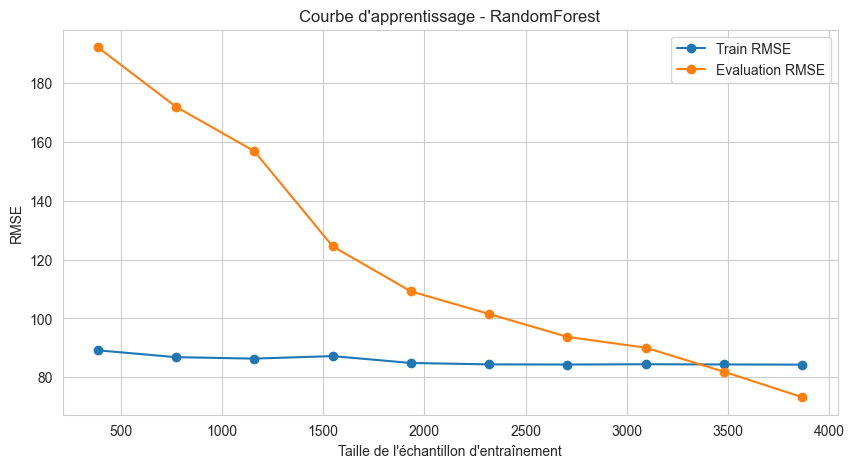

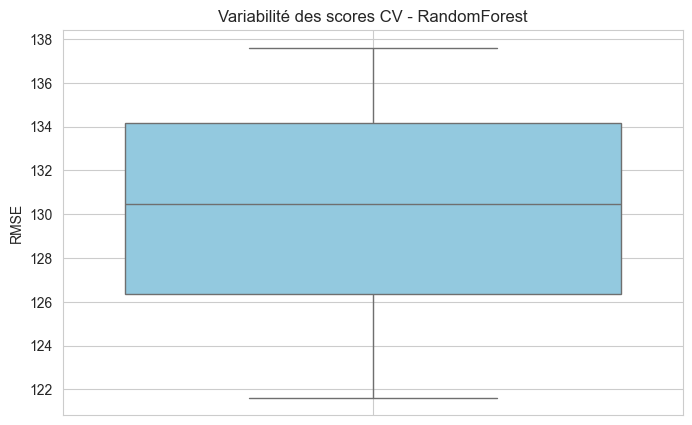

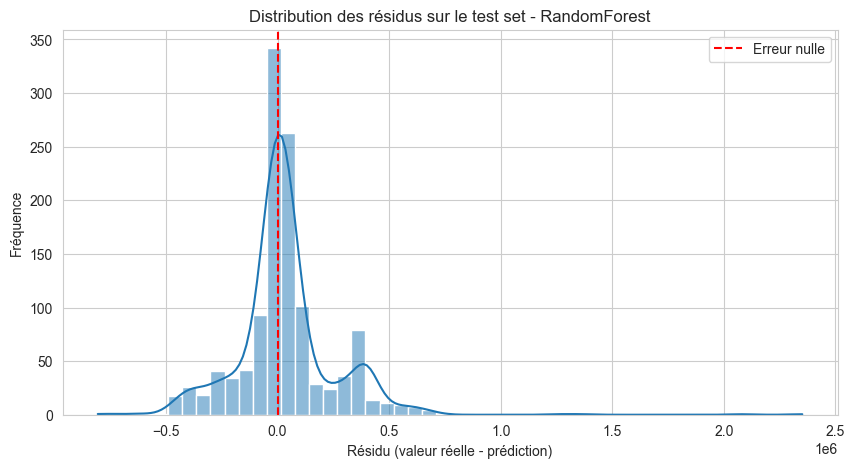

In [19]:
# Evaluation de RandomForest avec les meilleurs hyperparamètres
best_params = study.best_params
best_rf = RandomForestRegressor(n_estimators=150, max_depth=24, min_samples_split=4, 
                                min_samples_leaf=2, max_features=0.9983307961788621, max_samples=0.8926778632616932)

_ = evaluate_model(best_rf, "RandomForest", X_train_proc_df, y_train_trans, X_eval_proc_df, y_eval_trans, X_test_proc_df, y_test_trans, cv=4)

## Conclusion sur l'optimisation des hyperparamètres
On observe que l'optimisation n'a pas amélioré les performances, elle les a plutot légèrement dégradées. 
Nous allons donc **Conserver notre modèle de base**.

In [20]:
# On récupère le modèle final avant de le sauvegarder et d'interpréter son fonctionnement
model_final = models['RandomForest']
display(model_final)
display(preprocessor)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [21]:
# Sauvegarde du modèle optimisé avec son préprocesseur
joblib.dump(preprocessor, os.path.join(output_path, 'preprocessor_optimized.pkl'))
joblib.dump(model_final, os.path.join(output_path, 'rf_optimized.pkl'))
print(f"Modèle optimisé sauvegardé dans {output_path}")

Modèle optimisé sauvegardé dans c:\Users\DELL\Documents\VEMV\business\work\ProjetPolytech\EstimationPrimesAssuranceAutomobile_v2\Outputs\Modelisation


## 3. Interprétabilité avec SHAP

Dans cette section, nous utilisons **SHAP (SHapley Additive exPlanations)** pour interpréter les prédictions de notre modèle XGBoost optimisé. SHAP permet de décomposer chaque prédiction en contributions de chaque feature, offrant ainsi une vision claire de l'impact de chaque variable.

Nous allons produire trois types de visualisations :
1. **Beeswarm plot** : vue globale de l'impact de chaque feature sur les prédictions.
2. **Barplot** : importance moyenne des features basée sur les valeurs SHAP absolues.
3. **Waterfall plot** : explication détaillée d'une prédiction individuelle (nous choisissons une prime très élevée pour comprendre ses déterminants).

### 3.1 Import de SHAP et préparation des données

In [22]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du modèle optimisé et du préprocesseur (si besoin)
# Normalement, nous avons déjà best_xgb, X_train_proc_df, X_test_proc_df en mémoire.
# Nous allons utiliser un sous-ensemble de test pour le calcul SHAP (par exemple 1000 lignes)
sample_size = 1000
X_test_sample = X_test_proc_df.sample(n=sample_size, random_state=42)

# Vérification que les colonnes sont bien nommées
print("Noms des features :", X_test_sample.columns.tolist())

Noms des features : ['age_vehicule_annees', 'duree_garantie_jours', 'places', 'puissance', 'categorie_mère', 'garantie', 'segment', 'typeinter', 'ville', 'marque']


### 3.2 Calcul des valeurs SHAP
Nous utilisons TreeExplainer qui est optimisé pour les modèles basés sur les arbres (XGBoost, LightGBM, RandomForest, etc.).

In [23]:
# Création de l'explainer SHAP
explainer = shap.TreeExplainer(model_final)

# Calcul des SHAP values pour l'échantillon de test
shap_values = explainer.shap_values(X_test_sample)

# Vérification des dimensions
print(f"Shape des SHAP values : {shap_values.shape}")  # (n_samples, n_features)

# Les SHAP values sont dans l'espace transformé (sqrt de la cible). 
# Cela reste cohérent pour l'interprétation.

Shape des SHAP values : (1000, 10)


### 3.3 Affichage du Beeswarm plot
Le Beeswarm plot est un graphique qui combine l'importance des features avec leur impact sur la prédiction. Chaque point représente une observation (ici une ligne de l'échantillon test). La position sur l'axe des x indique la contribution de la feature (SHAP value), et la couleur indique la valeur de la feature (rouge = élevée, bleu = faible).

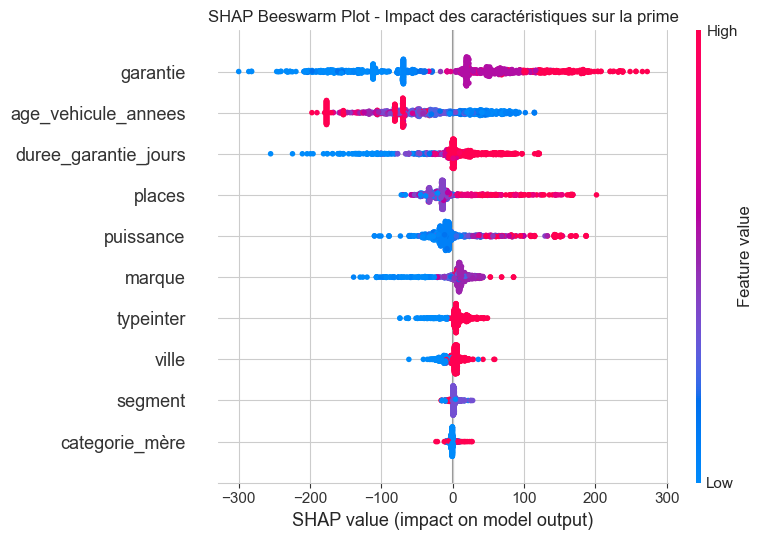

In [24]:
# Beeswarm plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Beeswarm Plot - Impact des caractéristiques sur la prime")
plt.tight_layout()
plt.show()

### 3.4 Affichage du Barplot (importance moyenne): SHAP vs Feature Importance natif
Le barplot affiche la moyenne des valeurs absolues des SHAP values pour chaque feature, donnant une mesure globale de l'importance de chaque variable.

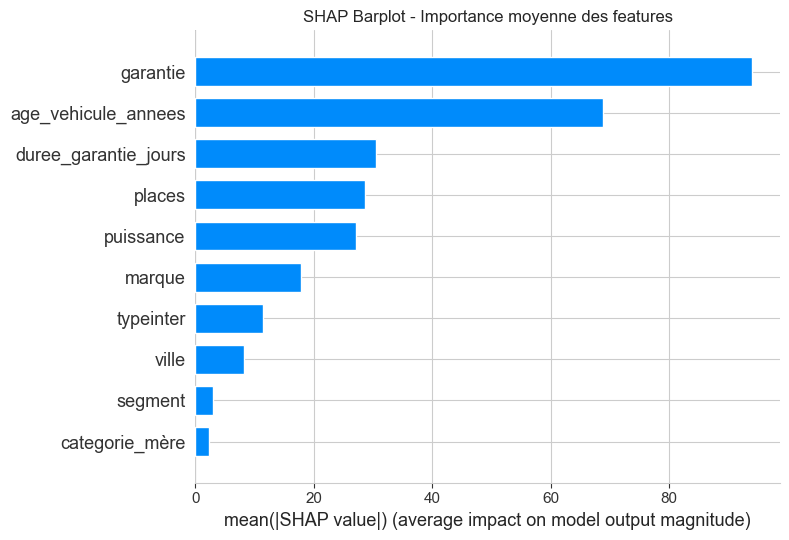

In [25]:
# Barplot SHAP
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Barplot - Importance moyenne des features")
plt.tight_layout()
plt.show()

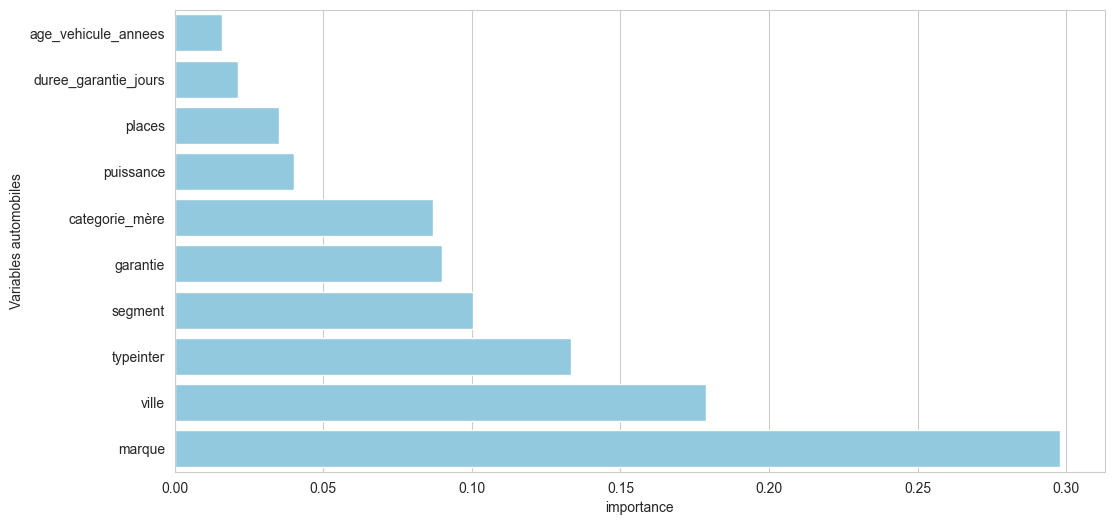

In [26]:
importances = model_final.feature_importances_
importances.sort()
labels = model_final.feature_names_in_

plt.figure()
sns.barplot(y=labels, x=importances, color='skyblue')
plt.xlabel("importance")
plt.ylabel("Variables automobiles")
plt.show()

### 3.5 Waterfall plot pour une prédiction outlier
Nous sélectionnons une observation dont la prime prédite est très élevée (par exemple dans le top 5% des prédictions). Nous utilisons ensuite un waterfall plot pour décomposer cette prédiction.

Indice de l'outlier : 755
Valeur prédite (originale) : 1337763.82


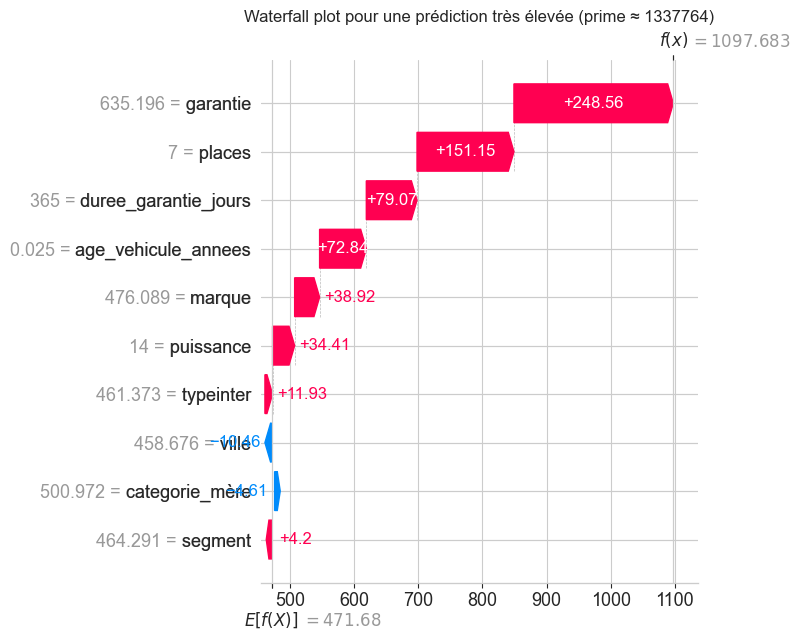

In [27]:
# Prédictions sur l'échantillon test
y_pred_sample = best_rf.predict(X_test_sample)
y_pred_orig_sample = y_pred_sample ** 2  # retour à l'échelle originale (inverse de sqrt)

# Sélection de l'indice de la prédiction la plus élevée
idx_outlier = np.argmax(y_pred_orig_sample)
print(f"Indice de l'outlier : {idx_outlier}")
print(f"Valeur prédite (originale) : {y_pred_orig_sample[idx_outlier]:.2f}")

# Waterfall plot pour cette observation
# shap.force_plot est une alternative interactive, mais pour un affichage statique on utilise waterfall_plot
# La fonction waterfall_plot de shap nécessite l'expected_value et les SHAP values pour une seule observation

# Récupération de la valeur de base (expected value)
expected_value = explainer.expected_value

# SHAP values pour l'observation choisie
shap_values_single = shap_values[idx_outlier, :]

# Création du waterfall plot
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_single,
        base_values=expected_value,
        data=X_test_sample.iloc[idx_outlier, :],
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Waterfall plot pour une prédiction très élevée (prime ≈ {y_pred_orig_sample[idx_outlier]:.0f})")
plt.tight_layout()
plt.show()

In [28]:
# Sauvegarde du modèle
import pickle
model_path = os.path.join(project_path, 'Outputs', 'Modelisation', 'rf_optimized.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(model_final, f)